# UFO Data Analysis Project

In [ ]:
import pandas as pd
import seaborn as sns   
import matplotlib.pyplot as plt
import us

df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2023/2023-06-20/ufo_sightings.csv")

print(df.columns.tolist())
print(df["country_code"].unique())
print(df["reported_date_time"].min(), df["reported_date_time"].max()) #goes up to 2023 
df = df[(df["duration_seconds"] > 0) & (df["duration_seconds"] < 86400)]# removing some extreme outliers that are more than 24 hours (86400 seconds) and less than 0 seconds
print(df.shape)
print(df.head(10))
df = df[df["state"].notna()]  # drop NaN first
print(df["reported_date_time"].dtype) # chekciong to see if it is datweteime formwart, if not we will have to convert it
df["reported_date_time"] = pd.to_datetime(df["reported_date_time"], errors='coerce') # convert to datetime, if there are any errors, it will set those to NaT (Not a Time)
print(df["reported_date_time"].dtype) # check again to confirm conversion
df = df.drop_duplicates() # drop duplicates
df = df[["reported_date_time","country_code","state"]]  # full_state_names gets dropped here!
df = df.dropna(subset=["reported_date_time"])
print(df.shape)
df["year"] = df["reported_date_time"].dt.year
df = df.drop("reported_date_time", axis=1) # we will drop the original reported_date_time column since we have extracted the year from it
df = df[(df["year"] <=2023) & (df["year"] >=2016) & (df["country_code"] == "US")]
print(df.shape)
print(df.head(10))                                      


hello
(21605, 3) shape of the data after dropping duplicates
(21591, 4)
   full_state_names  year  report_count
0           Alabama  2016            36
1           Alabama  2017            47
2           Alabama  2018            17
3           Alabama  2019            40
4           Alabama  2020            38
5           Alabama  2021            13
6           Alabama  2022            34
7           Alabama  2023            10
8            Alaska  2016            30
9            Alaska  2017            19
10           Alaska  2018            18
11           Alaska  2019            14
12           Alaska  2020             9
13           Alaska  2021             3
14           Alaska  2022             4
15           Alaska  2023             1
16          Arizona  2016           190
17          Arizona  2017           158
18          Arizona  2018            71
19          Arizona  2019           149


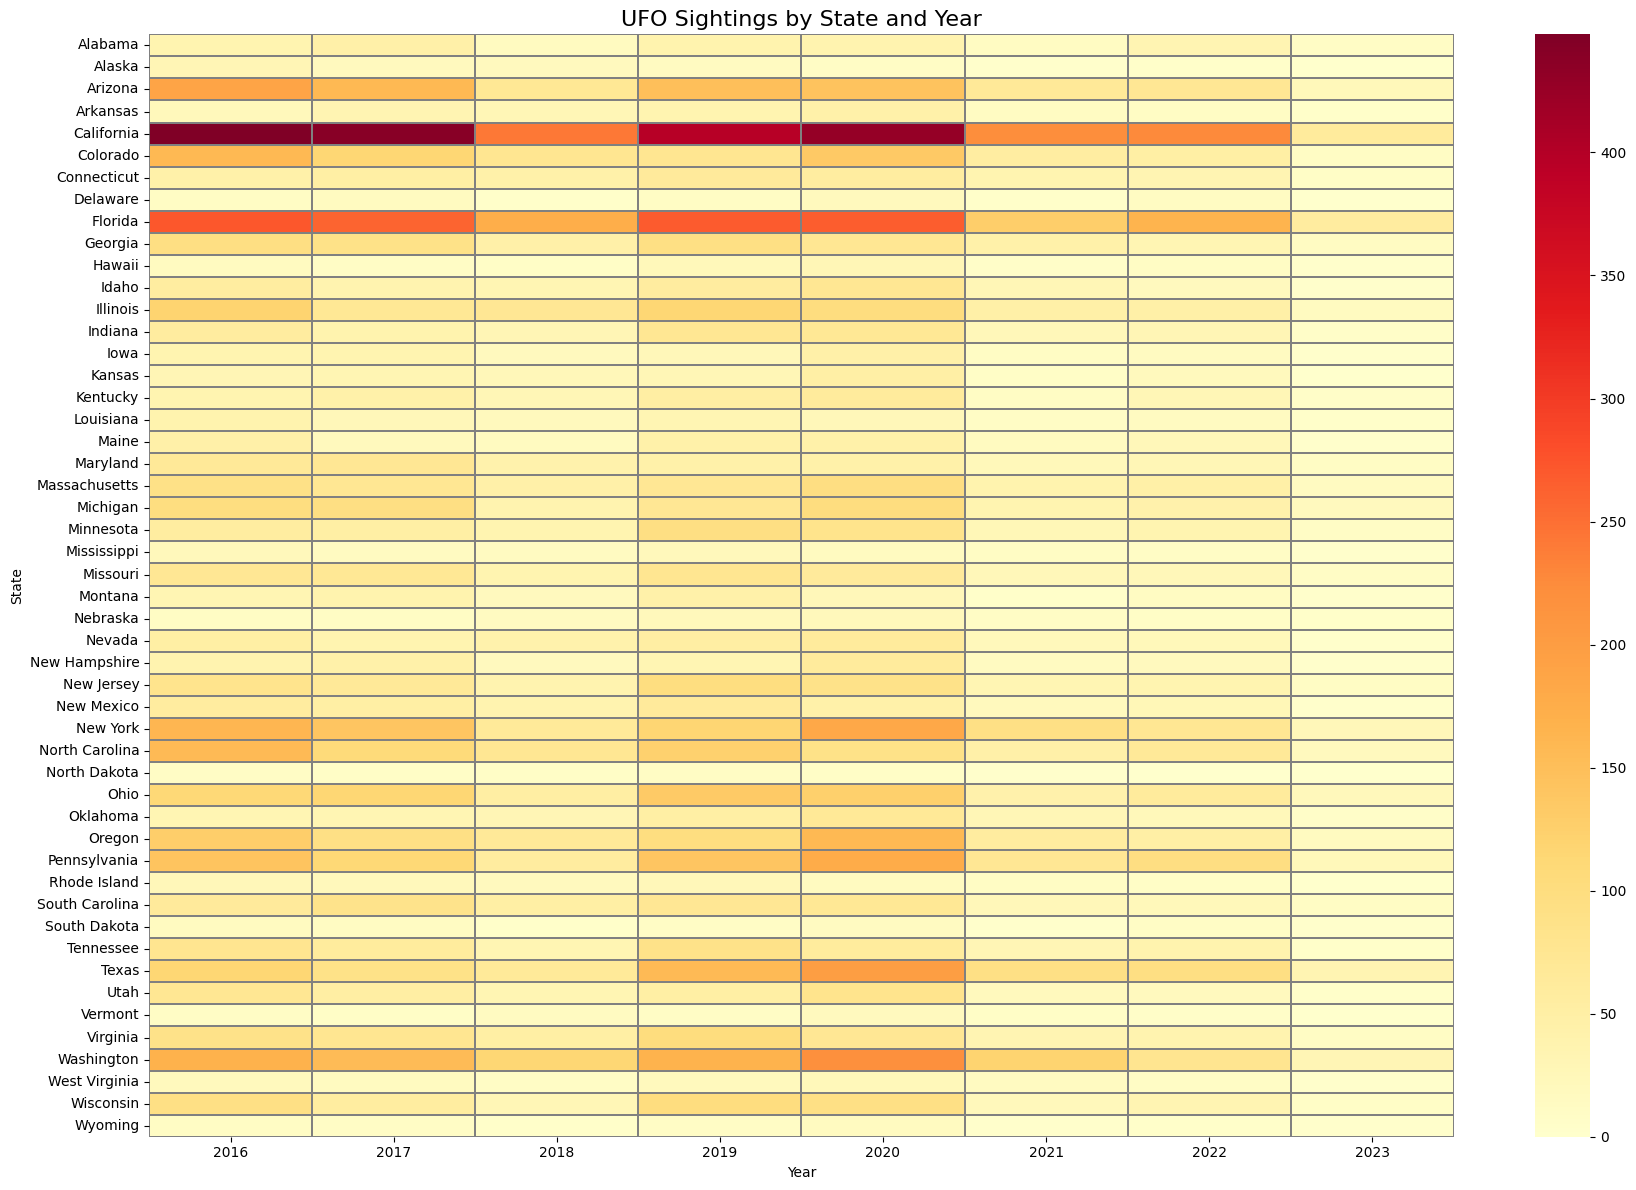

In [ ]:
print("hello", flush=True)

#more data cleqaning, we will remove any rows with missing values in the city column
print(df.shape,'shape of the data after dropping duplicates') 
# some more cleaning, we will remove any rows with missing values in the city column
df = df.dropna(subset=["state","year","country_code"]) # remove any rows where city or reported_date_time is missing  
df["full_state_names"] = df["state"].apply(lambda x: us.states.lookup(x).name if us.states.lookup(x) else None)
df = df.dropna(subset=["full_state_names"])

print(df.shape)
df.head(10)
state_counts = df.groupby(["full_state_names", "year"]).size().reset_index(name="report_count")
print(state_counts.head(20))

pivot = state_counts.pivot(index="full_state_names", columns="year", values="report_count").fillna(0)


# plot

pivot = pivot.sort_index()
plt.figure(figsize=(18, 12))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="grey")
plt.title("UFO Sightings by State and Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# Clustering on UFO Sightings

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np

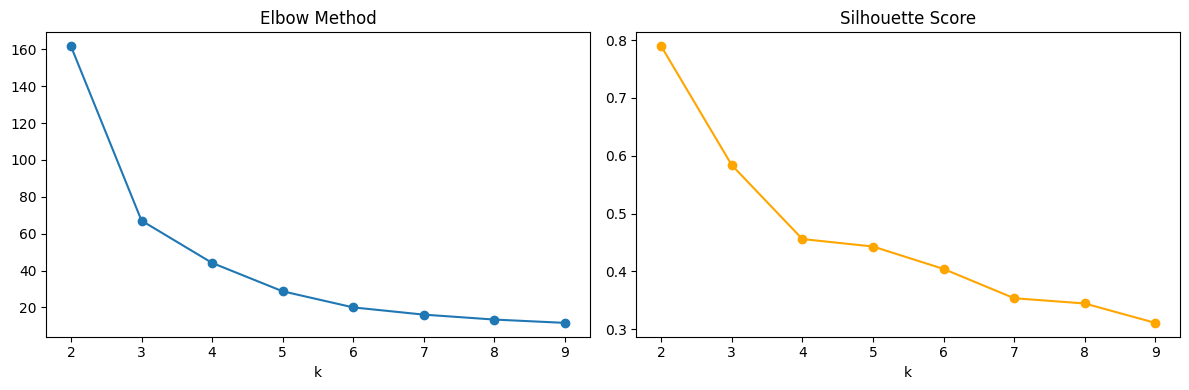

In [ ]:
# normalizing
scaler = StandardScaler()
pivot_scaled = scaler.fit_transform(pivot)

# determining optimal number of clusters
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pivot_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pivot_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k")
axes[1].plot(K_range, sil_scores, marker='o', color='orange')
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

In [ ]:
# fitting the model 
k = 4

km = KMeans(n_clusters=k, random_state=42, n_init=10)
pivot["cluster"] = km.fit_predict(pivot_scaled)

# determining which states are in each cluster
for c in range(k):
    states_in = pivot[pivot["cluster"] == c].index.tolist()
    print(f"\nCluster {c}: {states_in}")


Cluster 0: ['Connecticut', 'Georgia', 'Idaho', 'Indiana', 'Kentucky', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Missouri', 'Nevada', 'New Jersey', 'New Mexico', 'Oklahoma', 'South Carolina', 'Tennessee', 'Utah', 'Virginia', 'Wisconsin']

Cluster 1: ['California', 'Florida']

Cluster 2: ['Arizona', 'Colorado', 'Illinois', 'New York', 'North Carolina', 'Ohio', 'Oregon', 'Pennsylvania', 'Texas', 'Washington']

Cluster 3: ['Alabama', 'Alaska', 'Arkansas', 'Delaware', 'Hawaii', 'Iowa', 'Kansas', 'Louisiana', 'Maine', 'Mississippi', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Rhode Island', 'South Dakota', 'Vermont', 'West Virginia', 'Wyoming']


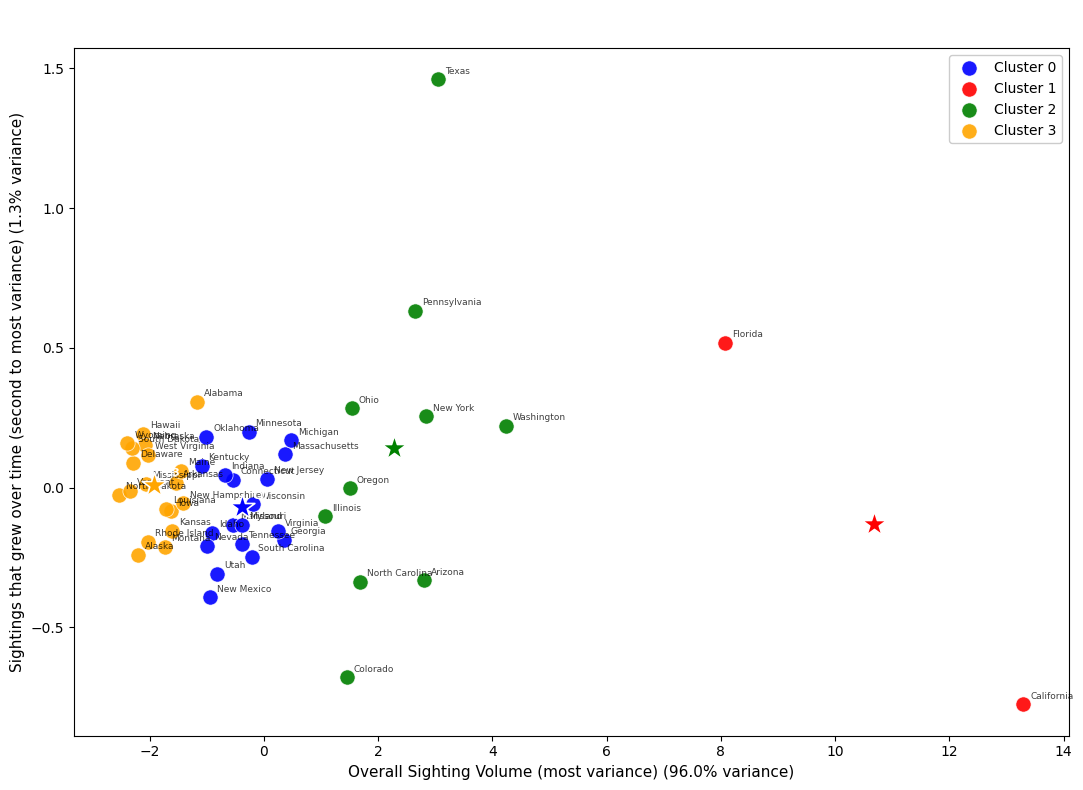

In [ ]:
# making 2D so it's plottable
pca = PCA(n_components=2)
coords = pca.fit_transform(pivot_scaled)

colors = ["blue", "red", "green", "orange"]
cluster_labels = pivot["cluster"].values

fig, ax = plt.subplots(figsize=(11, 8))

# plotting each cluster
for c in range(k):
    mask = cluster_labels == c
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=colors[c], s=120, alpha=0.9,
        edgecolors="white", linewidths=0.5,
        label=f"Cluster {c}", zorder=3
    )

# plotting cluster centroids, stars represent center
centroids_scaled = km.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

for c in range(k):
    ax.scatter(
        centroids_pca[c, 0], centroids_pca[c, 1],
        c=colors[c], s=350, marker="*",
        edgecolors="white", linewidths=1.2,
        zorder=5  # draw on top of everything
    )
    ax.annotate(
        f"C{c}",
        (centroids_pca[c, 0], centroids_pca[c, 1]),
        fontsize=8, color="white", fontweight="bold",
        xytext=(8, 6), textcoords="offset points", zorder=6
    )

# giving each point the name of a state
states = pivot.index.tolist()
for i, state in enumerate(states):
    ax.annotate(
        state,
        (coords[i, 0], coords[i, 1]),
        fontsize=6.5, color="black", alpha=0.75,
        xytext=(5, 4), textcoords="offset points"
    )

# labelling
var_explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"Overall Sighting Volume (most variance) ({var_explained[0]:.1f}% variance)", color="black", fontsize=11)
ax.set_ylabel(f"Sightings that grew over time (second to most variance) ({var_explained[1]:.1f}% variance)", color="black", fontsize=11)
ax.set_title("UFO Sighting Clusters by State (2016–2023)", 
             fontsize=15, color="white", pad=16, fontweight="bold")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
ax.legend(framealpha=0.2, labelcolor="black", facecolor="white", edgecolor="black", fontsize=10)

plt.tight_layout()
plt.show()


# Simple Linear Regression Implementation

In [ ]:
import numpy as np
import os

# read through climate data
climate_dfs = []
for filename in os.listdir("climate_data"):   
    if filename.endswith(".csv"):
        state_name = filename.replace(".csv", "").title()
        temp_df = pd.read_csv(f"climate_data/{filename}", skiprows=2)  
        temp_df["full_state_names"] = state_name
        climate_dfs.append(temp_df)

climate = pd.concat(climate_dfs, ignore_index=True)
climate["year"] = climate["Date"].astype(str).str[:4].astype(int)
climate_agg = (
    climate.groupby(["full_state_names", "year"])["Value"]
    .mean()
    .reset_index(name="avg_temp")
)
climate_agg = climate_agg[(climate_agg["year"] >= 2016) & (climate_agg["year"] <= 2023)]

merged = state_counts.merge(climate_agg, on=["full_state_names", "year"], how="inner")

# # Test
# print(f"Merged shape: {merged.shape}")
# print(merged.head())

class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  
   
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

Coefficient (slope): 1.5552
Intercept: -25.8936
R² Score: 0.0453


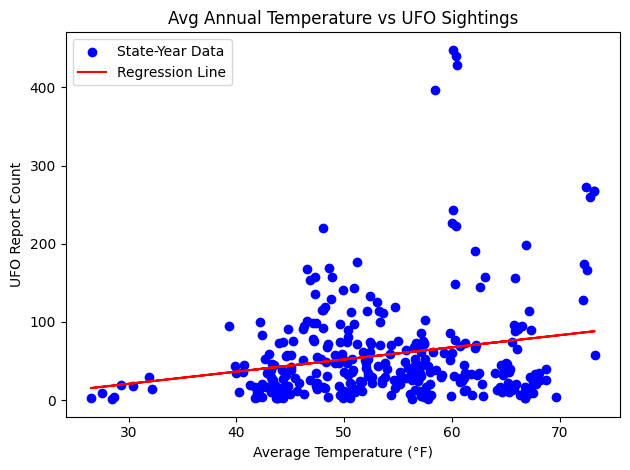

In [ ]:
X = merged["avg_temp"].values.reshape(-1, 1)
y = merged["report_count"].values

slr = SimpleLinearRegression()
slr.fit(X, y)

print(f"Coefficient (slope): {slr.coefficients_[1]:.4f}")
print(f"Intercept: {slr.intercept_:.4f}")
print(f"R² Score: {slr.r2score_:.4f}")

plt.scatter(X, y, color="blue", label="State-Year Data")
plt.plot(X, slr.y_pred_, color="red", label="Regression Line")
plt.title("Avg Annual Temperature vs UFO Sightings")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("UFO Report Count")
plt.legend()
plt.tight_layout()
plt.show()